<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/am_fm_pm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📻 Modulações Analógicas: AM · FM · PM
### Explicação preparada com auxílio do LLM Claude.

---

## O que é modulação analógica?

Imagine que você quer transmitir **voz ou música** pelo ar usando ondas de rádio.

O problema: o som tem frequências muito baixas (20 Hz – 20 kHz) e não viaja bem como onda eletromagnética. A solução é **montar o sinal de áudio dentro de uma onda portadora de alta frequência** — isso é a modulação.

```
Sinal de mensagem m(t)  +  Portadora A·cos(2π·fc·t)  →  Sinal modulado s(t)
```

Existem três parâmetros da portadora que podem ser variados:

| Modulação | O que varia | Parâmetro |
|-----------|------------|----------|
| **AM** | Amplitude Modulation | Amplitude A(t) |
| **FM** | Frequency Modulation | Frequência f(t) |
| **PM** | Phase Modulation | Fase φ(t) |

> 💡 Nos três casos, a portadora original é: $s_c(t) = A_c \cdot \cos(2\pi f_c t)$
>
> A mensagem $m(t)$ é um sinal de baixa frequência (ex: voz, música, senóide de teste).

In [1]:
# ── Importações ────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.signal import hilbert

plt.rcParams.update({
    'figure.facecolor': '#f5f7fa',
    'axes.facecolor':   '#ffffff',
    'axes.grid':        True,
    'grid.alpha':       0.25,
    'grid.linestyle':   '--',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'font.size':        11,
})

# ── Parâmetros globais ─────────────────────────────────────────
fs   = 8000          # taxa de amostragem (Hz)
T    = 0.2           # duração do sinal (s)
t    = np.linspace(0, T, int(fs*T), endpoint=False)

fc   = 200.0         # frequência da portadora (Hz)
fm   = 20.0          # frequência da mensagem (Hz)
Ac   = 1.0           # amplitude da portadora
Am   = 1.0           # amplitude da mensagem

# ── Sinal de mensagem (senóide simples) ────────────────────────
m_t  = Am * np.cos(2 * np.pi * fm * t)

# ── Portadora ─────────────────────────────────────────────────
c_t  = Ac * np.cos(2 * np.pi * fc * t)

print(f'Taxa de amostragem : {fs} Hz')
print(f'Duração            : {T} s  ({len(t)} amostras)')
print(f'Portadora          : fc = {fc} Hz,  Ac = {Ac}')
print(f'Mensagem           : fm = {fm} Hz,  Am = {Am}')
print('✅ Parâmetros configurados!')

Taxa de amostragem : 8000 Hz
Duração            : 0.2 s  (1600 amostras)
Portadora          : fc = 200.0 Hz,  Ac = 1.0
Mensagem           : fm = 20.0 Hz,  Am = 1.0
✅ Parâmetros configurados!


---
## 🔍 Os Ingredientes: Mensagem e Portadora

Antes de modular, vamos visualizar os dois sinais separadamente.

- **Mensagem $m(t)$**: sinal de baixa frequência que queremos transmitir
- **Portadora $c(t)$**: onda de alta frequência que serve de "veículo"

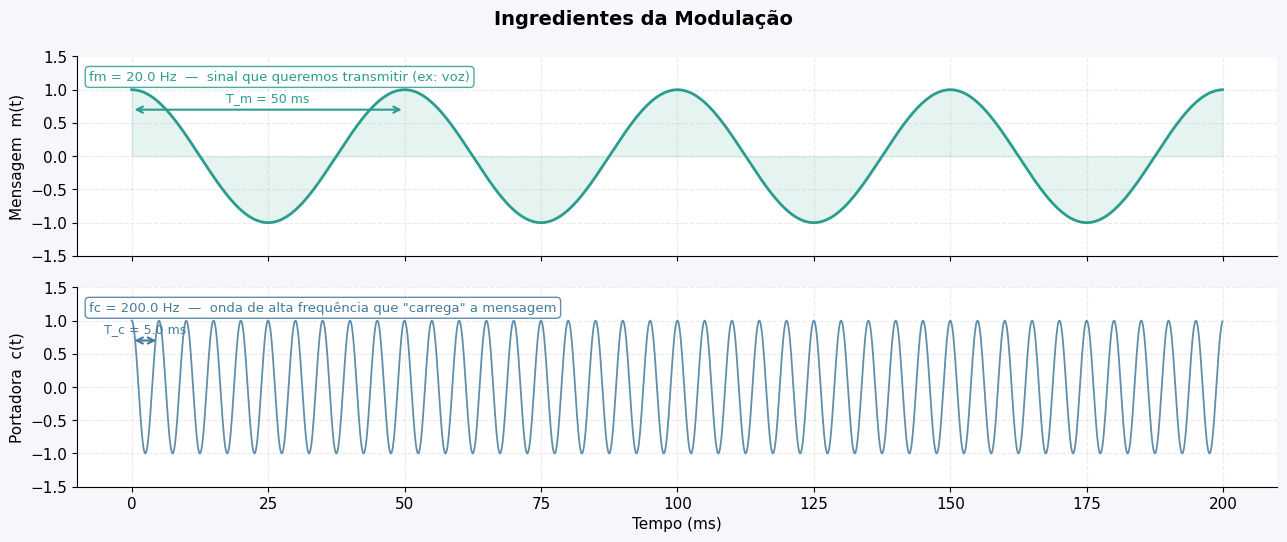

✅ Ingredientes visualizados!


In [2]:
fig, axes = plt.subplots(2, 1, figsize=(13, 5.5), sharex=True)
fig.suptitle('Ingredientes da Modulação', fontsize=14, fontweight='bold')

axes[0].plot(t*1000, m_t, color='#2a9d8f', lw=2)
axes[0].fill_between(t*1000, m_t, 0, alpha=0.12, color='#2a9d8f')
axes[0].set_ylabel('Mensagem  m(t)', fontsize=11)
axes[0].set_ylim(-1.5, 1.5)
axes[0].text(0.01, 0.88, f'fm = {fm} Hz  —  sinal que queremos transmitir (ex: voz)',
             transform=axes[0].transAxes, fontsize=9.5, color='#2a9d8f',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#2a9d8f', alpha=0.85))

axes[1].plot(t*1000, c_t, color='#457b9d', lw=1.3, alpha=0.85)
axes[1].set_ylabel('Portadora  c(t)', fontsize=11)
axes[1].set_ylim(-1.5, 1.5)
axes[1].set_xlabel('Tempo (ms)', fontsize=11)
axes[1].text(0.01, 0.88, f'fc = {fc} Hz  —  onda de alta frequência que "carrega" a mensagem',
             transform=axes[1].transAxes, fontsize=9.5, color='#457b9d',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                       edgecolor='#457b9d', alpha=0.85))

# Anotação de período
axes[0].annotate('', xy=(1000/fm, 0.7), xytext=(0, 0.7),
                 arrowprops=dict(arrowstyle='<->', color='#2a9d8f', lw=1.5))
axes[0].text(1000/(2*fm), 0.82, f'T_m = {1000/fm:.0f} ms', ha='center',
             fontsize=9, color='#2a9d8f')

axes[1].annotate('', xy=(1000/fc, 0.7), xytext=(0, 0.7),
                 arrowprops=dict(arrowstyle='<->', color='#457b9d', lw=1.5))
axes[1].text(1000/(2*fc), 0.82, f'T_c = {1000/fc:.1f} ms', ha='center',
             fontsize=9, color='#457b9d')

plt.tight_layout()
plt.savefig('00_ingredients.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Ingredientes visualizados!')

---
# 📻 PARTE 1 — AM (Amplitude Modulation)

## O que é AM?

Na AM, a **amplitude** da portadora varia de acordo com a mensagem.
A frequência permanece constante.

$$\boxed{s_{AM}(t) = A_c \bigl[1 + k_a \cdot m(t)\bigr] \cos(2\pi f_c t)}$$

onde:
- $k_a$ = índice de modulação (0 a 1 para AM convencional)
- Quando $m(t)$ sobe → envelope sobe
- Quando $m(t)$ desce → envelope desce

### Índice de modulação AM:
$$\mu = k_a \cdot A_m$$

- $\mu < 1$ → modulação normal (sinal pode ser demodulado facilmente)
- $\mu = 1$ → modulação a 100%
- $\mu > 1$ → **supermodulação** → distorção!

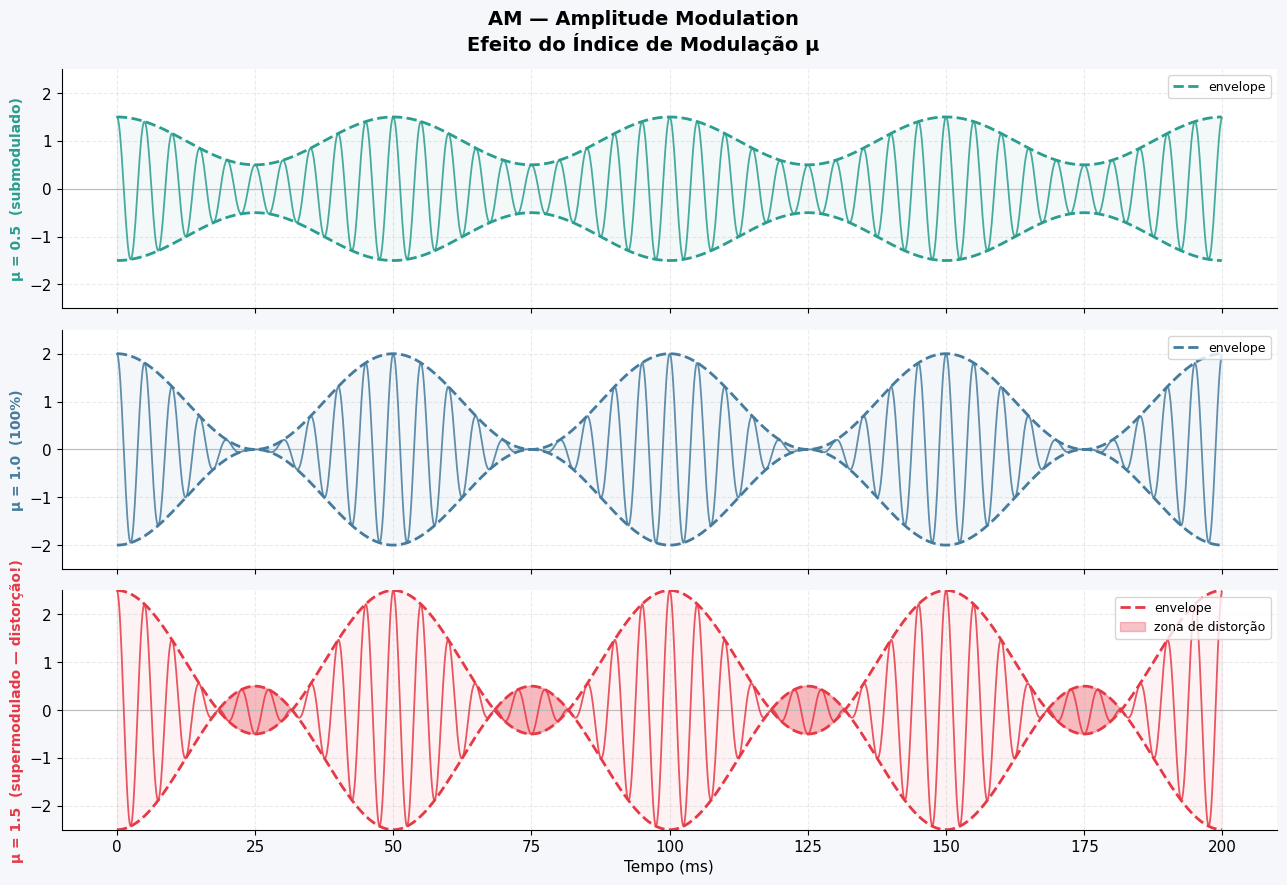

✅ AM — índices de modulação gerados!


In [3]:
# ── Gera sinais AM para 3 índices ──────────────────────────────
ka_values = [0.5, 1.0, 1.5]
labels_am = ['μ = 0.5  (submodulado)', 'μ = 1.0  (100%)', 'μ = 1.5  (supermodulado — distorção!)']
colors_am = ['#2a9d8f', '#457b9d', '#e63946']

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle('AM — Amplitude Modulation\nEfeito do Índice de Modulação μ',
             fontsize=14, fontweight='bold')

for ax, ka, lbl, col in zip(axes, ka_values, labels_am, colors_am):
    s_am = Ac * (1 + ka * m_t) * np.cos(2*np.pi*fc*t)
    env_pos =  Ac * (1 + ka * m_t)
    env_neg = -Ac * (1 + ka * m_t)

    ax.plot(t*1000, s_am, color=col, lw=1.3, alpha=0.85, zorder=3)
    ax.plot(t*1000, env_pos, color=col, lw=2, linestyle='--',
            label='envelope', zorder=4)
    ax.plot(t*1000, env_neg, color=col, lw=2, linestyle='--', zorder=4)
    ax.fill_between(t*1000, env_pos, env_neg, alpha=0.06, color=col)
    ax.axhline(0, color='#bbb', lw=0.8)

    if ka > 1:
        # marca regiões de supermodulação
        clip = Ac * (1 + ka * m_t)
        over = clip < 0
        ax.fill_between(t*1000, env_pos, env_neg,
                        where=over, alpha=0.3, color='#e63946',
                        label='zona de distorção')

    ax.set_ylabel(lbl, fontsize=10, color=col, fontweight='bold')
    ax.set_ylim(-2.5, 2.5)
    ax.legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Tempo (ms)', fontsize=11)
plt.tight_layout()
plt.savefig('01_am_modulation_index.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ AM — índices de modulação gerados!')

## AM — Espectro de Frequência

O espectro AM é muito revelador: a portadora gera um pico em $f_c$, e a mensagem aparece como **bandas laterais** simétricas em $f_c \pm f_m$.

```
Espectro AM:

        fc-fm     fc     fc+fm
          |        |        |
        banda    portadora  banda
        lateral             lateral
```

A largura de banda AM é: $B_{AM} = 2 \cdot f_m$

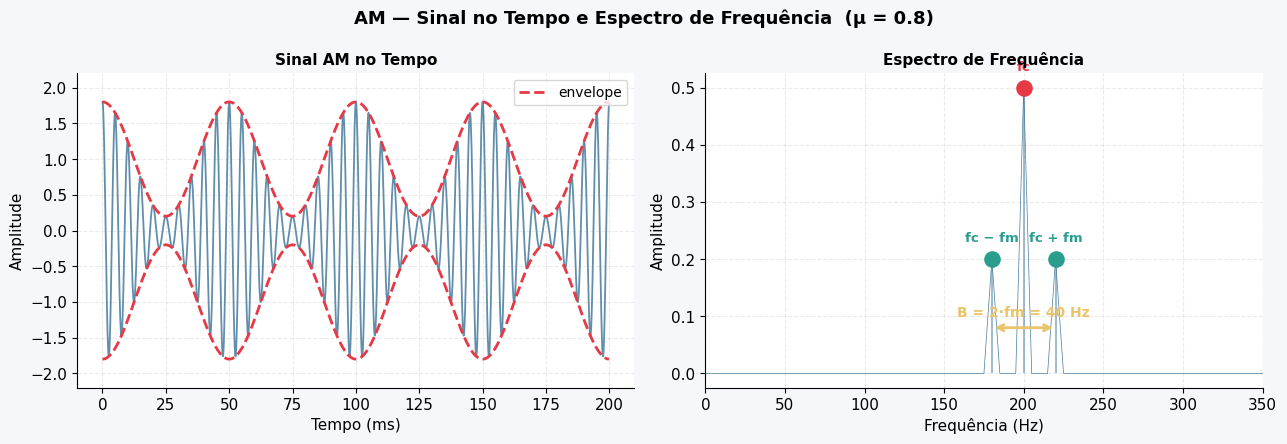

✅ Espectro AM gerado!


In [4]:
ka = 0.8
s_am = Ac * (1 + ka * m_t) * np.cos(2*np.pi*fc*t)

# FFT
def plot_spectrum(ax, signal, fs, color, title, xlim=(0, 400)):
    N   = len(signal)
    S   = np.abs(np.fft.rfft(signal)) / N
    f   = np.fft.rfftfreq(N, 1/fs)
    ax.stem(f, S, linefmt=color, markerfmt=color+'o',
            basefmt='gray', use_line_collection=True)
    ax.set_xlim(*xlim)
    ax.set_xlabel('Frequência (Hz)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('AM — Sinal no Tempo e Espectro de Frequência  (μ = 0.8)',
             fontsize=13, fontweight='bold')

# Tempo
axes[0].plot(t*1000, s_am, color='#457b9d', lw=1.3, alpha=0.85)
axes[0].plot(t*1000,  Ac*(1+ka*m_t), color='#e63946', lw=2, linestyle='--', label='envelope')
axes[0].plot(t*1000, -Ac*(1+ka*m_t), color='#e63946', lw=2, linestyle='--')
axes[0].set_xlabel('Tempo (ms)', fontsize=11)
axes[0].set_ylabel('Amplitude', fontsize=11)
axes[0].set_title('Sinal AM no Tempo', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_ylim(-2.2, 2.2)

# Espectro
N = len(s_am)
S = np.abs(np.fft.rfft(s_am)) / N
f = np.fft.rfftfreq(N, 1/fs)
# Picos esperados: fc-fm, fc, fc+fm
axes[1].vlines(f, 0, S, color='#457b9d', lw=1.2, alpha=0.6)
axes[1].plot(f, S, color='#457b9d', lw=0.5)
# Destaca os 3 picos
for freq, lbl, col in [(fc-fm,'fc − fm','#2a9d8f'),
                        (fc,   'fc',     '#e63946'),
                        (fc+fm,'fc + fm','#2a9d8f')]:
    idx = np.argmin(np.abs(f - freq))
    axes[1].scatter(f[idx], S[idx], s=120, color=col, zorder=6)
    axes[1].annotate(lbl, (f[idx], S[idx]),
                     xytext=(f[idx], S[idx]+0.03),
                     ha='center', fontsize=9.5, color=col, fontweight='bold')

# Largura de banda
axes[1].annotate('', xy=(fc+fm, 0.08), xytext=(fc-fm, 0.08),
                 arrowprops=dict(arrowstyle='<->', color='#e9c46a', lw=2))
axes[1].text(fc, 0.10, f'B = 2·fm = {2*fm:.0f} Hz',
             ha='center', fontsize=10, color='#e9c46a', fontweight='bold')

axes[1].set_xlim(0, 350)
axes[1].set_xlabel('Frequência (Hz)', fontsize=11)
axes[1].set_ylabel('Amplitude', fontsize=11)
axes[1].set_title('Espectro de Frequência', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('02_am_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Espectro AM gerado!')

## AM — Demodulação por Detector de Envelope

A beleza do AM é que a **demodulação é simples**: basta seguir o envelope do sinal.

O **detector de envelope** (circuito com diodo + RC) faz exatamente isso no rádio AM.

```
Sinal AM  →  [Diodo]  →  [Filtro RC]  →  Mensagem recuperada
              retifica    suaviza
```

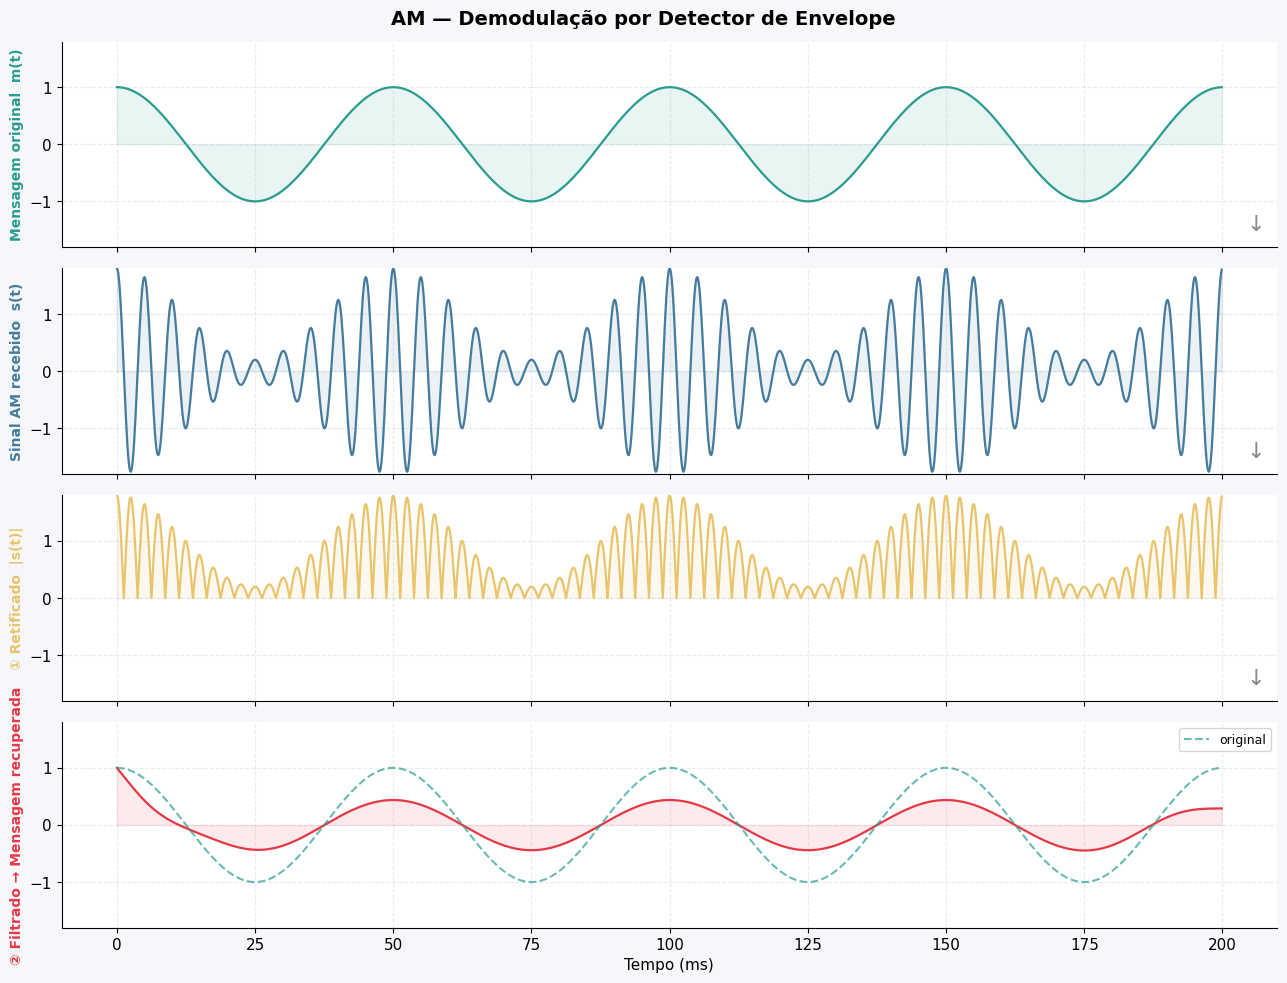

✅ Demodulação AM gerada!


In [5]:
from scipy.signal import butter, filtfilt

ka   = 0.8
s_am = Ac * (1 + ka * m_t) * np.cos(2*np.pi*fc*t)

# Etapa 1: retificação (simula diodo)
retificado = np.abs(s_am)

# Etapa 2: filtro passa-baixa (simula RC)
b, a = butter(4, fm*2.5 / (fs/2), btype='low')
envelope_det = filtfilt(b, a, retificado)

# Etapa 3: remove DC e normaliza
envelope_det -= np.mean(envelope_det)
envelope_det /= np.max(np.abs(envelope_det))

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle('AM — Demodulação por Detector de Envelope',
             fontsize=14, fontweight='bold')

config = [
    (m_t,          '#2a9d8f', 'Mensagem original  m(t)'),
    (s_am,         '#457b9d', 'Sinal AM recebido  s(t)'),
    (retificado,   '#e9c46a', '① Retificado  |s(t)|'),
    (envelope_det, '#e63946', '② Filtrado → Mensagem recuperada'),
]
for ax, (sig, col, lbl) in zip(axes, config):
    ax.plot(t*1000, sig, color=col, lw=1.6)
    ax.fill_between(t*1000, sig, 0, alpha=0.10, color=col)
    ax.set_ylabel(lbl, fontsize=10, color=col, fontweight='bold')
    ax.set_ylim(-1.8, 1.8)

# Superpõe mensagem original sobre recuperada
axes[3].plot(t*1000, m_t, color='#2a9d8f', lw=1.5, linestyle='--',
             alpha=0.7, label='original')
axes[3].legend(fontsize=9, loc='upper right')

axes[-1].set_xlabel('Tempo (ms)', fontsize=11)

# Setas de fluxo entre painéis
for i in range(3):
    axes[i].text(0.99, 0.08, '↓', transform=axes[i].transAxes,
                 ha='right', fontsize=16, color='#888')

plt.tight_layout()
plt.savefig('03_am_demod.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Demodulação AM gerada!')

---
# 📻 PARTE 2 — FM (Frequency Modulation)

## O que é FM?

Na FM, a **frequência** da portadora varia de acordo com a mensagem.
A amplitude permanece constante.

$$\boxed{s_{FM}(t) = A_c \cos\!\left(2\pi f_c t + 2\pi k_f \int_0^t m(\tau)\,d\tau\right)}$$

Para mensagem senoidal $m(t) = A_m\cos(2\pi f_m t)$:

$$s_{FM}(t) = A_c \cos\!\left(2\pi f_c t + \beta \sin(2\pi f_m t)\right)$$

onde $\beta = \dfrac{\Delta f}{f_m}$ é o **índice de modulação FM** e $\Delta f = k_f \cdot A_m$ é o **desvio de frequência**.

| Parâmetro | Significado |
|-----------|------------|
| $\Delta f$ | quanto a frequência se afasta de $f_c$ |
| $\beta$ | quanto a fase acumula (proporcional a $\Delta f$) |
| **Amplitude constante** | FM é resistente a ruído de amplitude! |

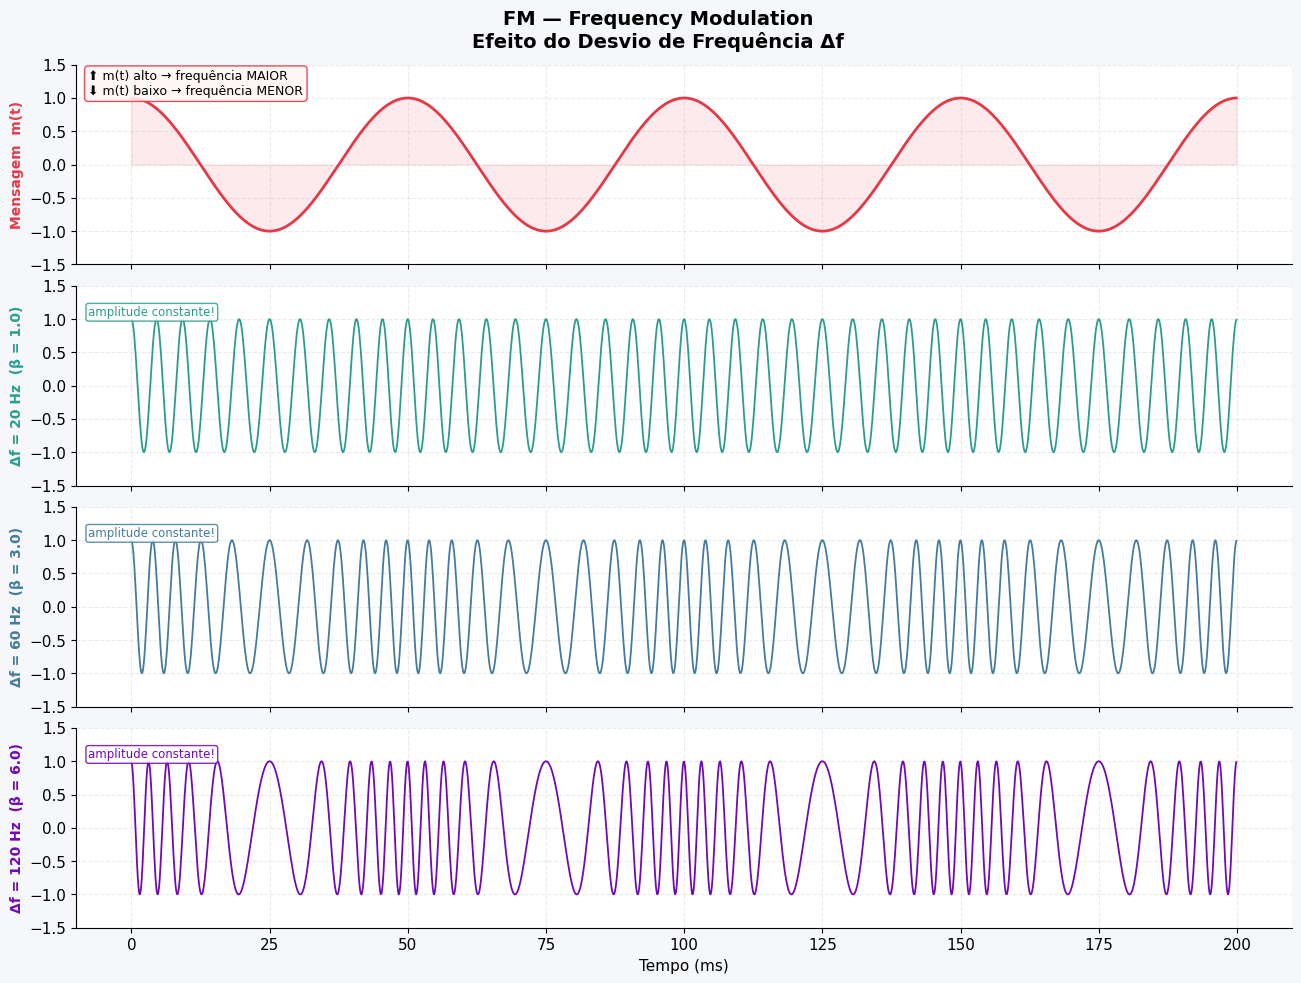

✅ FM gerado!


In [6]:
# ── Gera sinais FM para 3 desvios de frequência ───────────────
delta_f_values = [20, 60, 120]
labels_fm = [f'Δf = {df} Hz  (β = {df/fm:.1f})' for df in delta_f_values]
colors_fm = ['#2a9d8f', '#457b9d', '#7209b7']

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle('FM — Frequency Modulation\nEfeito do Desvio de Frequência Δf',
             fontsize=14, fontweight='bold')

# Painel 0: mensagem
axes[0].plot(t*1000, m_t, color='#e63946', lw=2)
axes[0].fill_between(t*1000, m_t, 0, alpha=0.10, color='#e63946')
axes[0].set_ylabel('Mensagem  m(t)', fontsize=10, color='#e63946', fontweight='bold')
axes[0].set_ylim(-1.5, 1.5)
axes[0].text(0.01, 0.85, '⬆ m(t) alto → frequência MAIOR\n⬇ m(t) baixo → frequência MENOR',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff5f5',
                       edgecolor='#e63946', alpha=0.9))

for ax, df, lbl, col in zip(axes[1:], delta_f_values, labels_fm, colors_fm):
    beta  = df / fm
    phi   = np.cumsum(m_t) / fs   # integral de m(t)
    s_fm  = Ac * np.cos(2*np.pi*fc*t + 2*np.pi*df*phi)

    ax.plot(t*1000, s_fm, color=col, lw=1.3)
    ax.set_ylabel(lbl, fontsize=10, color=col, fontweight='bold')
    ax.set_ylim(-1.5, 1.5)

    # Anotações visuais de compressão/expansão
    ax.text(0.01, 0.85, 'amplitude constante!',
            transform=ax.transAxes, fontsize=8.5, color=col,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=col, alpha=0.85))

axes[-1].set_xlabel('Tempo (ms)', fontsize=11)
plt.tight_layout()
plt.savefig('04_fm_modulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ FM gerado!')

## FM — Frequência Instantânea

A característica mais importante do FM é que a **frequência instantânea** segue a mensagem:

$$f_i(t) = f_c + k_f \cdot m(t) = f_c + \Delta f \cdot m_n(t)$$

Podemos visualizar isso extraindo a frequência instantânea do sinal.

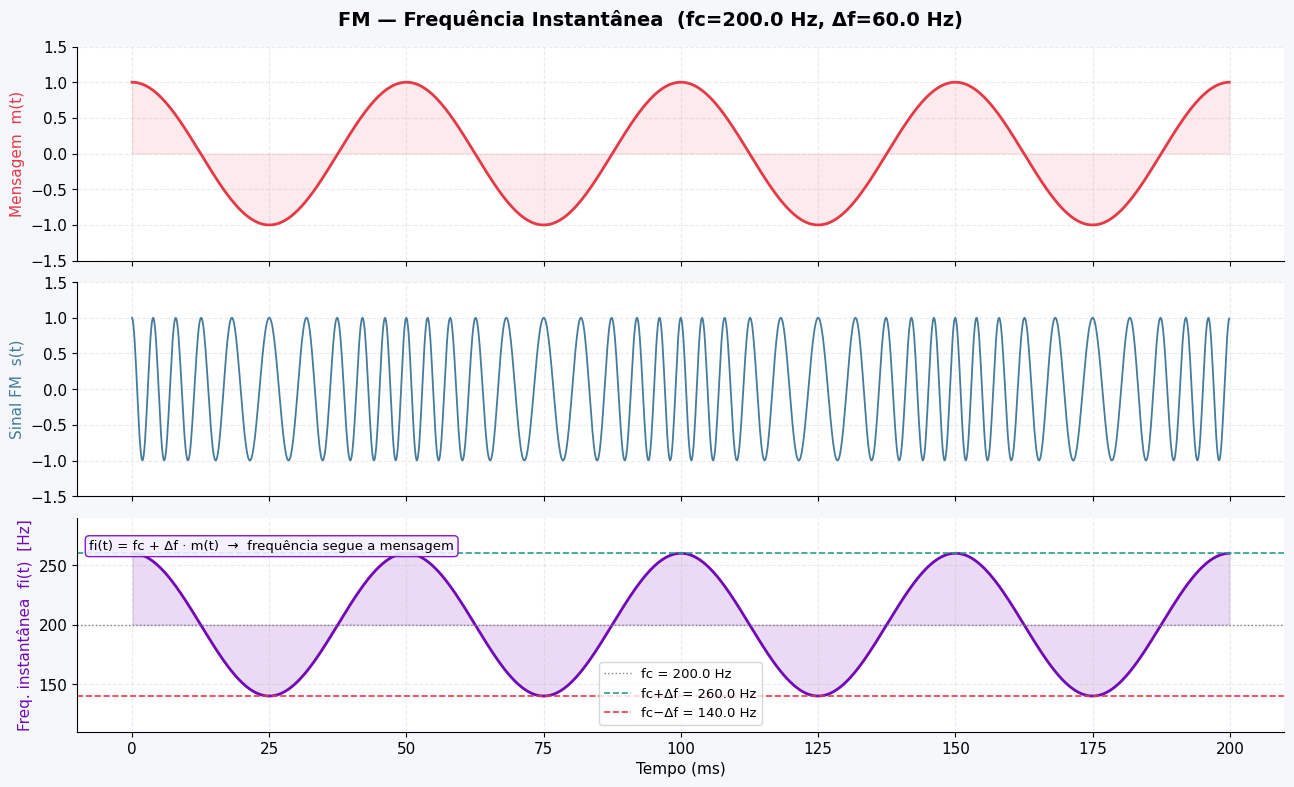

✅ Frequência instantânea gerada!


In [7]:
df    = 60.0
phi   = np.cumsum(m_t) / fs
s_fm  = Ac * np.cos(2*np.pi*fc*t + 2*np.pi*df*phi)

# Frequência instantânea via derivada da fase (transformada de Hilbert)
analytic  = hilbert(s_fm)
inst_phase = np.unwrap(np.angle(analytic))
inst_freq  = np.diff(inst_phase) / (2*np.pi) * fs

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
fig.suptitle(f'FM — Frequência Instantânea  (fc={fc} Hz, Δf={df} Hz)',
             fontsize=14, fontweight='bold')

axes[0].plot(t*1000, m_t, color='#e63946', lw=2)
axes[0].fill_between(t*1000, m_t, 0, alpha=0.10, color='#e63946')
axes[0].set_ylabel('Mensagem  m(t)', fontsize=11, color='#e63946')
axes[0].set_ylim(-1.5, 1.5)

axes[1].plot(t*1000, s_fm, color='#457b9d', lw=1.3)
axes[1].set_ylabel('Sinal FM  s(t)', fontsize=11, color='#457b9d')
axes[1].set_ylim(-1.5, 1.5)

axes[2].plot(t[1:]*1000, inst_freq, color='#7209b7', lw=2)
axes[2].axhline(fc,    color='gray', lw=1, linestyle=':',  label=f'fc = {fc} Hz')
axes[2].axhline(fc+df, color='#2a9d8f', lw=1.2, linestyle='--', label=f'fc+Δf = {fc+df} Hz')
axes[2].axhline(fc-df, color='#e63946', lw=1.2, linestyle='--', label=f'fc−Δf = {fc-df} Hz')
axes[2].fill_between(t[1:]*1000, inst_freq, fc, alpha=0.15, color='#7209b7')
axes[2].set_ylabel('Freq. instantânea  fi(t)  [Hz]', fontsize=11, color='#7209b7')
axes[2].set_ylim(fc-df*1.5, fc+df*1.5)
axes[2].legend(fontsize=9.5)
axes[2].set_xlabel('Tempo (ms)', fontsize=11)

# Anotação: mostra que fi segue m(t)
axes[2].text(0.01, 0.85,
             'fi(t) = fc + Δf · m(t)  →  frequência segue a mensagem',
             transform=axes[2].transAxes, fontsize=9.5,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f4eeff',
                       edgecolor='#7209b7', alpha=0.9))

plt.tight_layout()
plt.savefig('05_fm_inst_freq.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Frequência instantânea gerada!')

## FM — Espectro e Largura de Banda (Regra de Carson)

O espectro FM é mais complexo que o AM — contém **infinitas bandas laterais** (componentes de Bessel).

Na prática, usamos a **Regra de Carson** para estimar a largura de banda necessária:

$$\boxed{B_{FM} \approx 2(\Delta f + f_m) = 2 f_m (1 + \beta)}$$

Isso explica por que o **rádio FM (88–108 MHz) ocupa mais banda que o AM (530–1600 kHz)**.

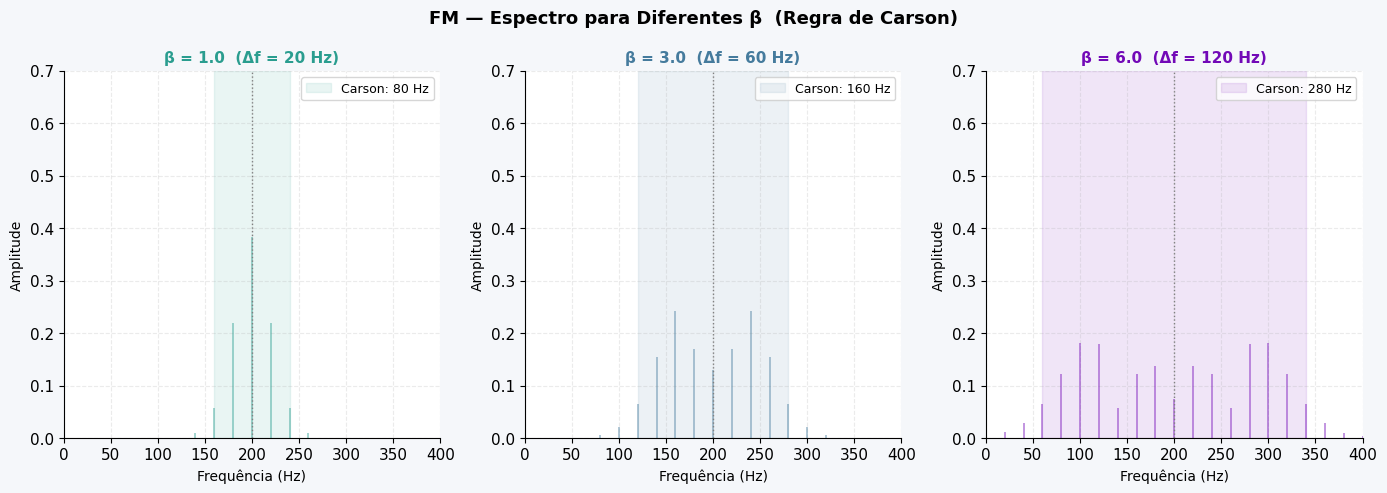

✅ Espectro FM gerado!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('FM — Espectro para Diferentes β  (Regra de Carson)',
             fontsize=13, fontweight='bold')

delta_f_vals = [20, 60, 120]
cols_sp = ['#2a9d8f', '#457b9d', '#7209b7']

for ax, df, col in zip(axes, delta_f_vals, cols_sp):
    beta   = df / fm
    phi    = np.cumsum(m_t) / fs
    s_fm_s = Ac * np.cos(2*np.pi*fc*t + 2*np.pi*df*phi)

    N   = len(s_fm_s)
    S   = np.abs(np.fft.rfft(s_fm_s)) / N
    f_  = np.fft.rfftfreq(N, 1/fs)

    ax.vlines(f_, 0, S, color=col, lw=1.2, alpha=0.5)
    ax.set_xlim(0, 400)
    ax.set_ylim(0, 0.7)

    B_carson = 2 * (df + fm)
    ax.axvspan(fc - B_carson/2, fc + B_carson/2, alpha=0.10,
               color=col, label=f'Carson: {B_carson:.0f} Hz')
    ax.axvline(fc, color='gray', lw=1, linestyle=':')

    ax.set_title(f'β = {beta:.1f}  (Δf = {df} Hz)', fontsize=11,
                 fontweight='bold', color=col)
    ax.set_xlabel('Frequência (Hz)', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('06_fm_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Espectro FM gerado!')

---
# 📻 PARTE 3 — PM (Phase Modulation)

## O que é PM?

Na PM, a **fase** da portadora varia proporcionalmente à mensagem.

$$\boxed{s_{PM}(t) = A_c \cos\bigl(2\pi f_c t + k_p \cdot m(t)\bigr)}$$

onde $k_p$ é a constante de modulação de fase (rad/V).

### PM vs FM: qual é a diferença?

| | PM | FM |
|-|----|----|
| **Fase** | proporcional a $m(t)$ | proporcional a $\int m(t)$ |
| **Frequência** | proporcional a $\frac{dm}{dt}$ | proporcional a $m(t)$ |
| **Amplitude** | constante | constante |

> 💡 **PM e FM são intimamente relacionados**: fazer FM é equivalente a fazer PM sobre o sinal *integrado*; e fazer PM é equivalente a fazer FM sobre o sinal *diferenciado*.
>
> Por isso na prática os transmissores FM às vezes usam modulação de fase internamente!

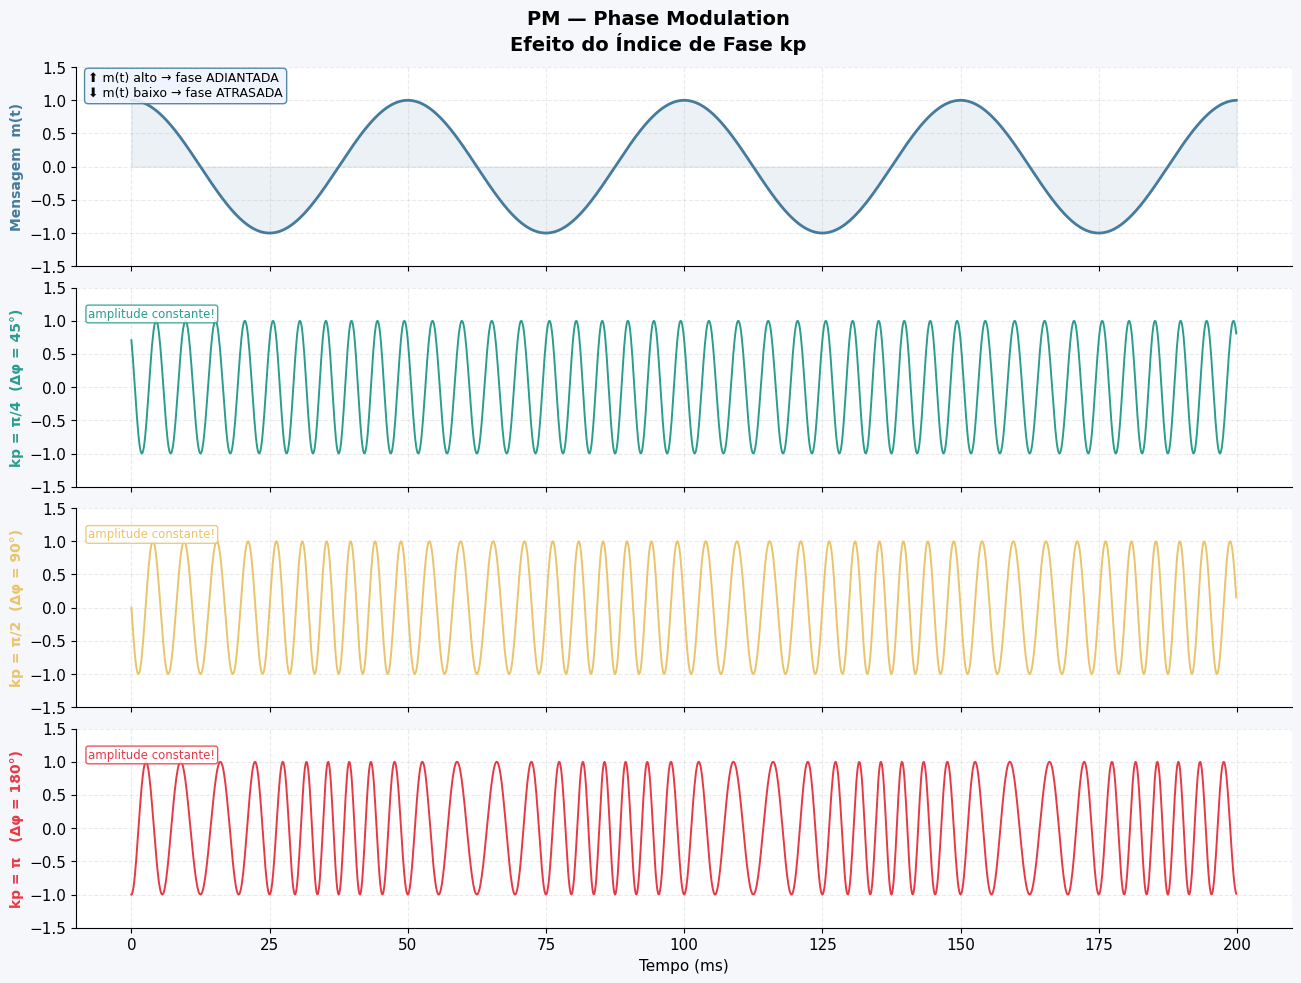

✅ PM gerado!


In [9]:
# ── Gera sinais PM para 3 índices de fase ──────────────────────
kp_values  = [np.pi/4, np.pi/2, np.pi]
labels_pm  = [f'kp = π/4  (Δφ = 45°)', 'kp = π/2  (Δφ = 90°)', 'kp = π   (Δφ = 180°)']
colors_pm  = ['#2a9d8f', '#e9c46a', '#e63946']

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle('PM — Phase Modulation\nEfeito do Índice de Fase kp',
             fontsize=14, fontweight='bold')

axes[0].plot(t*1000, m_t, color='#457b9d', lw=2)
axes[0].fill_between(t*1000, m_t, 0, alpha=0.10, color='#457b9d')
axes[0].set_ylabel('Mensagem  m(t)', fontsize=10, color='#457b9d', fontweight='bold')
axes[0].set_ylim(-1.5, 1.5)
axes[0].text(0.01, 0.85, '⬆ m(t) alto → fase ADIANTADA\n⬇ m(t) baixo → fase ATRASADA',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eef3ff',
                       edgecolor='#457b9d', alpha=0.9))

for ax, kp, lbl, col in zip(axes[1:], kp_values, labels_pm, colors_pm):
    s_pm = Ac * np.cos(2*np.pi*fc*t + kp*m_t)
    ax.plot(t*1000, s_pm, color=col, lw=1.4)
    ax.set_ylabel(lbl, fontsize=10, color=col, fontweight='bold')
    ax.set_ylim(-1.5, 1.5)
    ax.text(0.01, 0.85, 'amplitude constante!',
            transform=ax.transAxes, fontsize=8.5, color=col,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor=col, alpha=0.85))

axes[-1].set_xlabel('Tempo (ms)', fontsize=11)
plt.tight_layout()
plt.savefig('07_pm_modulation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PM gerado!')

## PM — Fase Instantânea

Na PM, é a **fase acumulada** que podemos visualizar diretamente — ela replica a forma da mensagem.

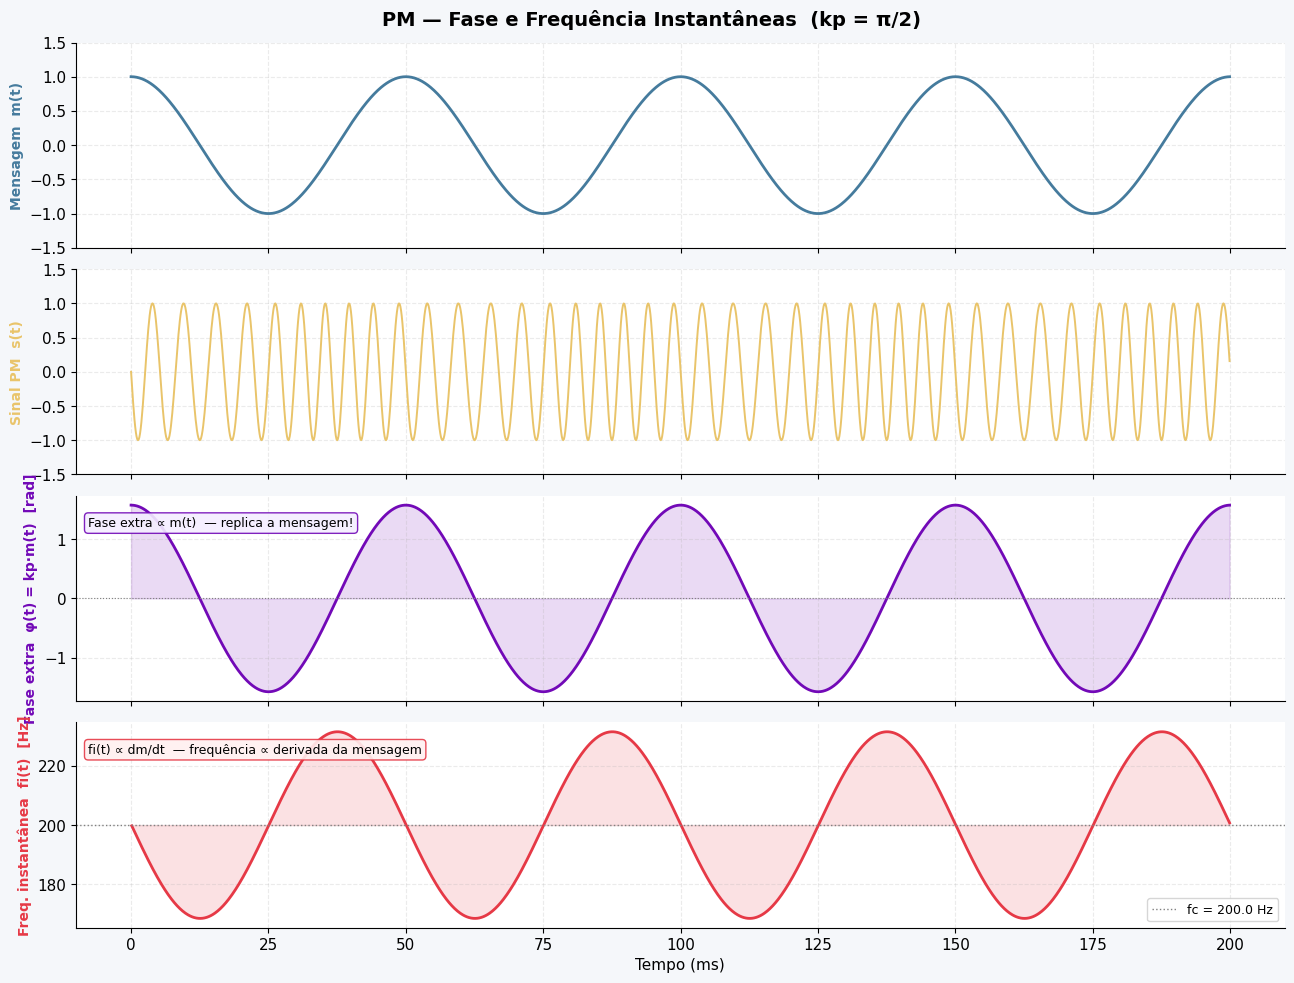

✅ Fase PM visualizada!


In [10]:
kp    = np.pi/2
s_pm  = Ac * np.cos(2*np.pi*fc*t + kp*m_t)

# Fase instantânea via Hilbert
analytic_pm = hilbert(s_pm)
inst_phase_pm = np.unwrap(np.angle(analytic_pm))
phase_excursion = inst_phase_pm - 2*np.pi*fc*t   # remove fase linear da portadora

# Frequência instantânea da PM
inst_freq_pm = np.diff(inst_phase_pm) / (2*np.pi) * fs

fig, axes = plt.subplots(4, 1, figsize=(13, 10), sharex=True)
fig.suptitle(f'PM — Fase e Frequência Instantâneas  (kp = π/2)',
             fontsize=14, fontweight='bold')

axes[0].plot(t*1000, m_t, color='#457b9d', lw=2)
axes[0].set_ylabel('Mensagem  m(t)', fontsize=10, color='#457b9d', fontweight='bold')
axes[0].set_ylim(-1.5, 1.5)

axes[1].plot(t*1000, s_pm, color='#e9c46a', lw=1.4)
axes[1].set_ylabel('Sinal PM  s(t)', fontsize=10, color='#e9c46a', fontweight='bold')
axes[1].set_ylim(-1.5, 1.5)

axes[2].plot(t*1000, phase_excursion, color='#7209b7', lw=2)
axes[2].axhline(0, color='gray', lw=0.8, linestyle=':')
axes[2].fill_between(t*1000, phase_excursion, 0, alpha=0.15, color='#7209b7')
axes[2].set_ylabel('Fase extra  φ(t) = kp·m(t)  [rad]',
                   fontsize=10, color='#7209b7', fontweight='bold')
axes[2].text(0.01, 0.85, 'Fase extra ∝ m(t)  — replica a mensagem!',
             transform=axes[2].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f4eeff',
                       edgecolor='#7209b7', alpha=0.9))

axes[3].plot(t[1:]*1000, inst_freq_pm, color='#e63946', lw=2)
axes[3].axhline(fc, color='gray', lw=1, linestyle=':', label=f'fc = {fc} Hz')
axes[3].fill_between(t[1:]*1000, inst_freq_pm, fc, alpha=0.15, color='#e63946')
axes[3].set_ylabel('Freq. instantânea  fi(t)  [Hz]',
                   fontsize=10, color='#e63946', fontweight='bold')
axes[3].legend(fontsize=9)
axes[3].text(0.01, 0.85, 'fi(t) ∝ dm/dt  — frequência ∝ derivada da mensagem',
             transform=axes[3].transAxes, fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff0f0',
                       edgecolor='#e63946', alpha=0.9))

axes[-1].set_xlabel('Tempo (ms)', fontsize=11)
plt.tight_layout()
plt.savefig('08_pm_phase.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Fase PM visualizada!')

---
# 🔍 PARTE 4 — Comparação AM vs FM vs PM

Vamos colocar os três lado a lado com **a mesma mensagem** e observar as diferenças.

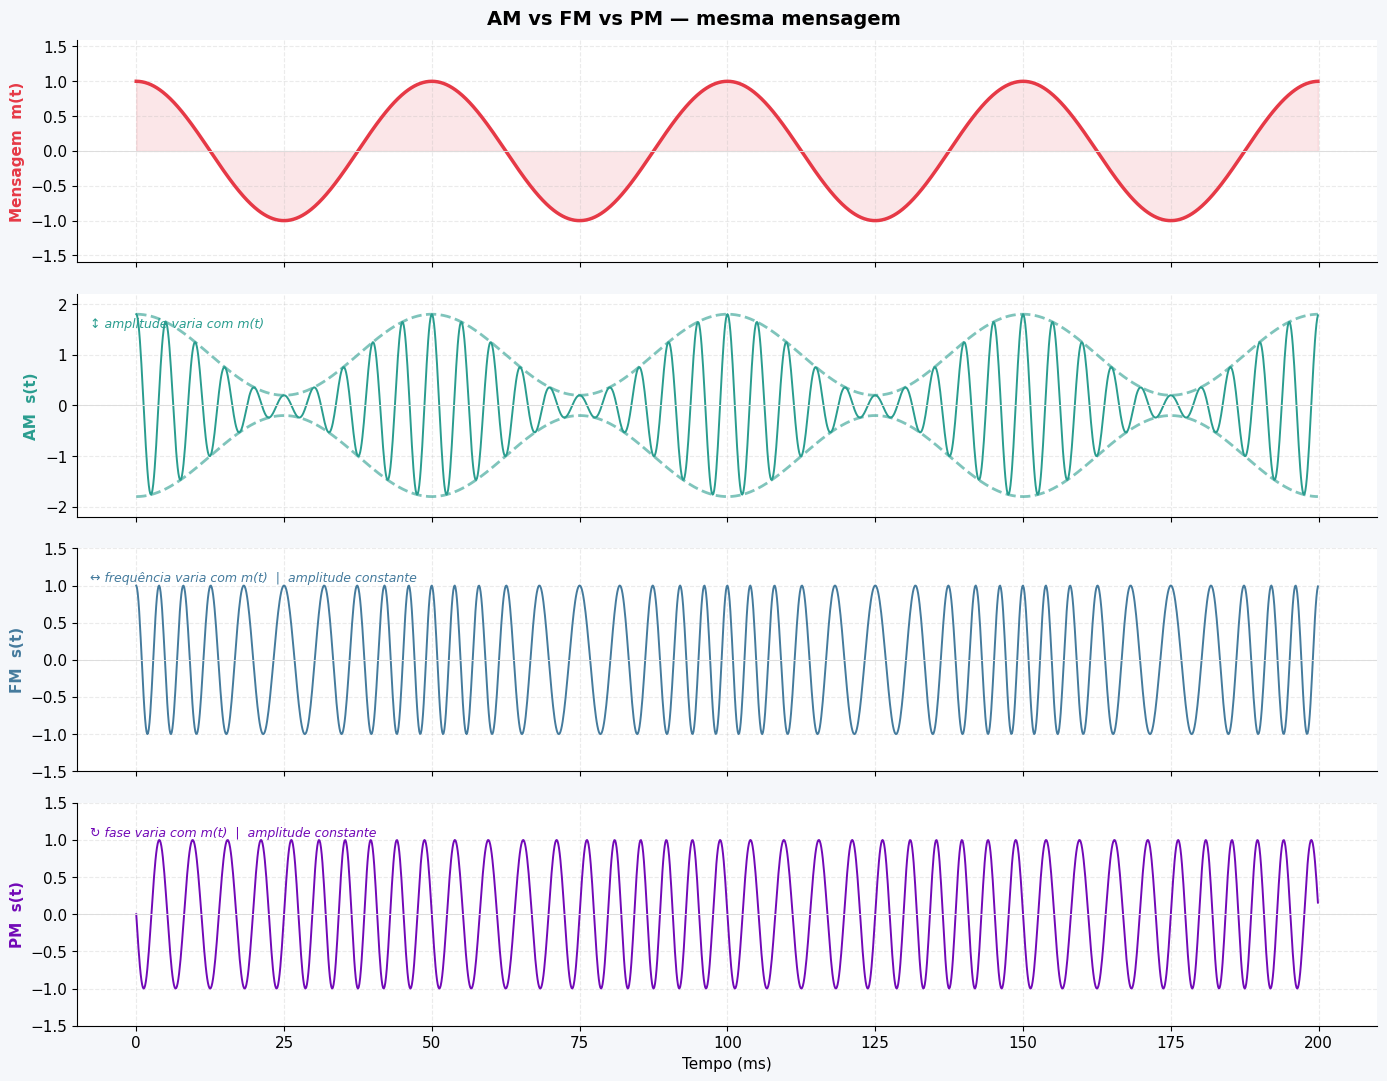

✅ Comparação AM vs FM vs PM gerada!


In [11]:
ka = 0.8
df = 60.0
kp = np.pi/2

s_am = Ac * (1 + ka*m_t) * np.cos(2*np.pi*fc*t)
phi  = np.cumsum(m_t) / fs
s_fm = Ac * np.cos(2*np.pi*fc*t + 2*np.pi*df*phi)
s_pm = Ac * np.cos(2*np.pi*fc*t + kp*m_t)

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
fig.suptitle('AM vs FM vs PM — mesma mensagem', fontsize=14, fontweight='bold')

# Mensagem
axes[0].plot(t*1000, m_t, color='#e63946', lw=2.5)
axes[0].fill_between(t*1000, m_t, 0, alpha=0.12, color='#e63946')
axes[0].set_ylabel('Mensagem  m(t)', fontsize=11, color='#e63946', fontweight='bold')
axes[0].set_ylim(-1.6, 1.6)

# AM
axes[1].plot(t*1000, s_am, color='#2a9d8f', lw=1.4)
axes[1].plot(t*1000,  Ac*(1+ka*m_t), color='#2a9d8f', lw=2, linestyle='--', alpha=0.6)
axes[1].plot(t*1000, -Ac*(1+ka*m_t), color='#2a9d8f', lw=2, linestyle='--', alpha=0.6)
axes[1].set_ylabel('AM  s(t)', fontsize=11, color='#2a9d8f', fontweight='bold')
axes[1].set_ylim(-2.2, 2.2)
axes[1].text(0.01, 0.85, '↕ amplitude varia com m(t)',
             transform=axes[1].transAxes, fontsize=9,
             color='#2a9d8f', style='italic')

# FM
axes[2].plot(t*1000, s_fm, color='#457b9d', lw=1.4)
axes[2].set_ylabel('FM  s(t)', fontsize=11, color='#457b9d', fontweight='bold')
axes[2].set_ylim(-1.5, 1.5)
axes[2].text(0.01, 0.85, '↔ frequência varia com m(t)  |  amplitude constante',
             transform=axes[2].transAxes, fontsize=9,
             color='#457b9d', style='italic')

# PM
axes[3].plot(t*1000, s_pm, color='#7209b7', lw=1.4)
axes[3].set_ylabel('PM  s(t)', fontsize=11, color='#7209b7', fontweight='bold')
axes[3].set_ylim(-1.5, 1.5)
axes[3].set_xlabel('Tempo (ms)', fontsize=11)
axes[3].text(0.01, 0.85, '↻ fase varia com m(t)  |  amplitude constante',
             transform=axes[3].transAxes, fontsize=9,
             color='#7209b7', style='italic')

# Separador visual entre sinais
for ax in axes:
    ax.axhline(0, color='#ddd', lw=0.7)

plt.tight_layout()
plt.savefig('09_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparação AM vs FM vs PM gerada!')

## Comparação dos Espectros

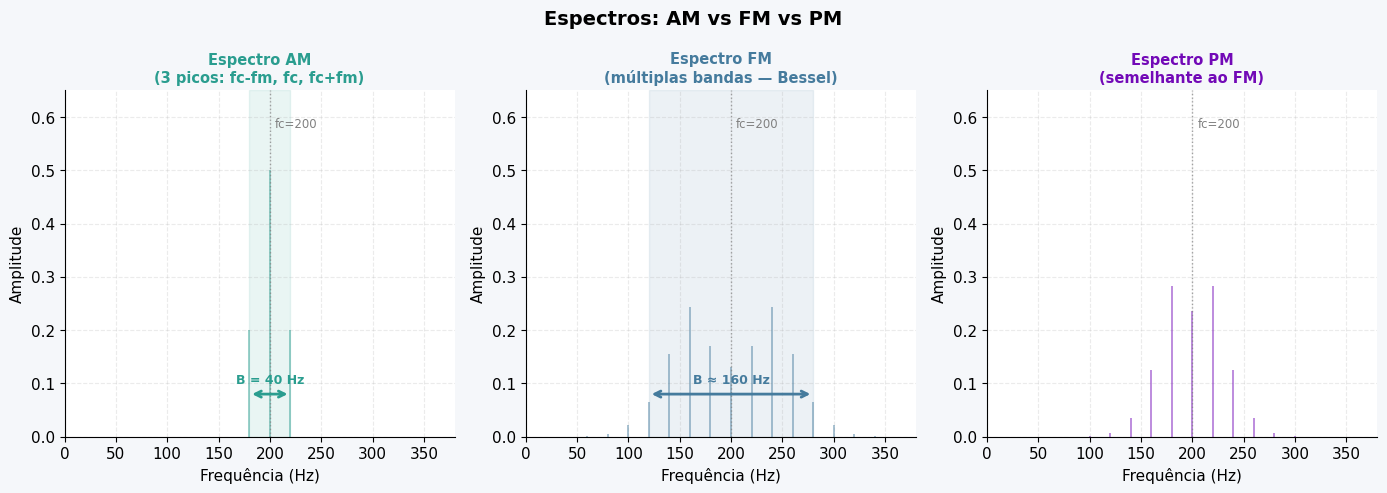

✅ Espectros comparados!


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Espectros: AM vs FM vs PM', fontsize=14, fontweight='bold')

specs = [(s_am, '#2a9d8f', 'Espectro AM\n(3 picos: fc-fm, fc, fc+fm)'),
         (s_fm, '#457b9d', 'Espectro FM\n(múltiplas bandas — Bessel)'),
         (s_pm, '#7209b7', 'Espectro PM\n(semelhante ao FM)')]

for ax, (sig, col, title) in zip(axes, specs):
    N_ = len(sig)
    S_ = np.abs(np.fft.rfft(sig)) / N_
    f_ = np.fft.rfftfreq(N_, 1/fs)
    ax.vlines(f_, 0, S_, color=col, lw=1.2, alpha=0.55)
    ax.set_xlim(0, 380)
    ax.set_ylim(0, 0.65)
    ax.axvline(fc, color='gray', lw=1, linestyle=':', alpha=0.7)
    ax.set_xlabel('Frequência (Hz)', fontsize=11)
    ax.set_ylabel('Amplitude', fontsize=11)
    ax.set_title(title, fontsize=10.5, fontweight='bold', color=col)
    ax.text(fc+5, 0.58, f'fc={fc:.0f}', fontsize=8.5, color='gray')

# Largura de banda AM
B_am = 2*fm
axes[0].axvspan(fc-B_am/2, fc+B_am/2, alpha=0.10, color='#2a9d8f')
axes[0].annotate('', xy=(fc+B_am/2, 0.08), xytext=(fc-B_am/2, 0.08),
                 arrowprops=dict(arrowstyle='<->', color='#2a9d8f', lw=2))
axes[0].text(fc, 0.10, f'B = {B_am:.0f} Hz', ha='center',
             fontsize=9, color='#2a9d8f', fontweight='bold')

# Largura de banda FM (Carson)
B_fm = 2*(df + fm)
axes[1].axvspan(fc-B_fm/2, fc+B_fm/2, alpha=0.10, color='#457b9d')
axes[1].annotate('', xy=(fc+B_fm/2, 0.08), xytext=(fc-B_fm/2, 0.08),
                 arrowprops=dict(arrowstyle='<->', color='#457b9d', lw=2))
axes[1].text(fc, 0.10, f'B ≈ {B_fm:.0f} Hz', ha='center',
             fontsize=9, color='#457b9d', fontweight='bold')

plt.tight_layout()
plt.savefig('10_spectra_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Espectros comparados!')

---
## Ruído: Por que FM é Melhor que AM?

O ruído afeta principalmente a **amplitude** do sinal recebido.

- **AM**: a informação está na amplitude → ruído deforma diretamente a mensagem
- **FM/PM**: a informação está na frequência/fase → amplitude constante → o receptor pode **limitar** a amplitude e eliminar o ruído!

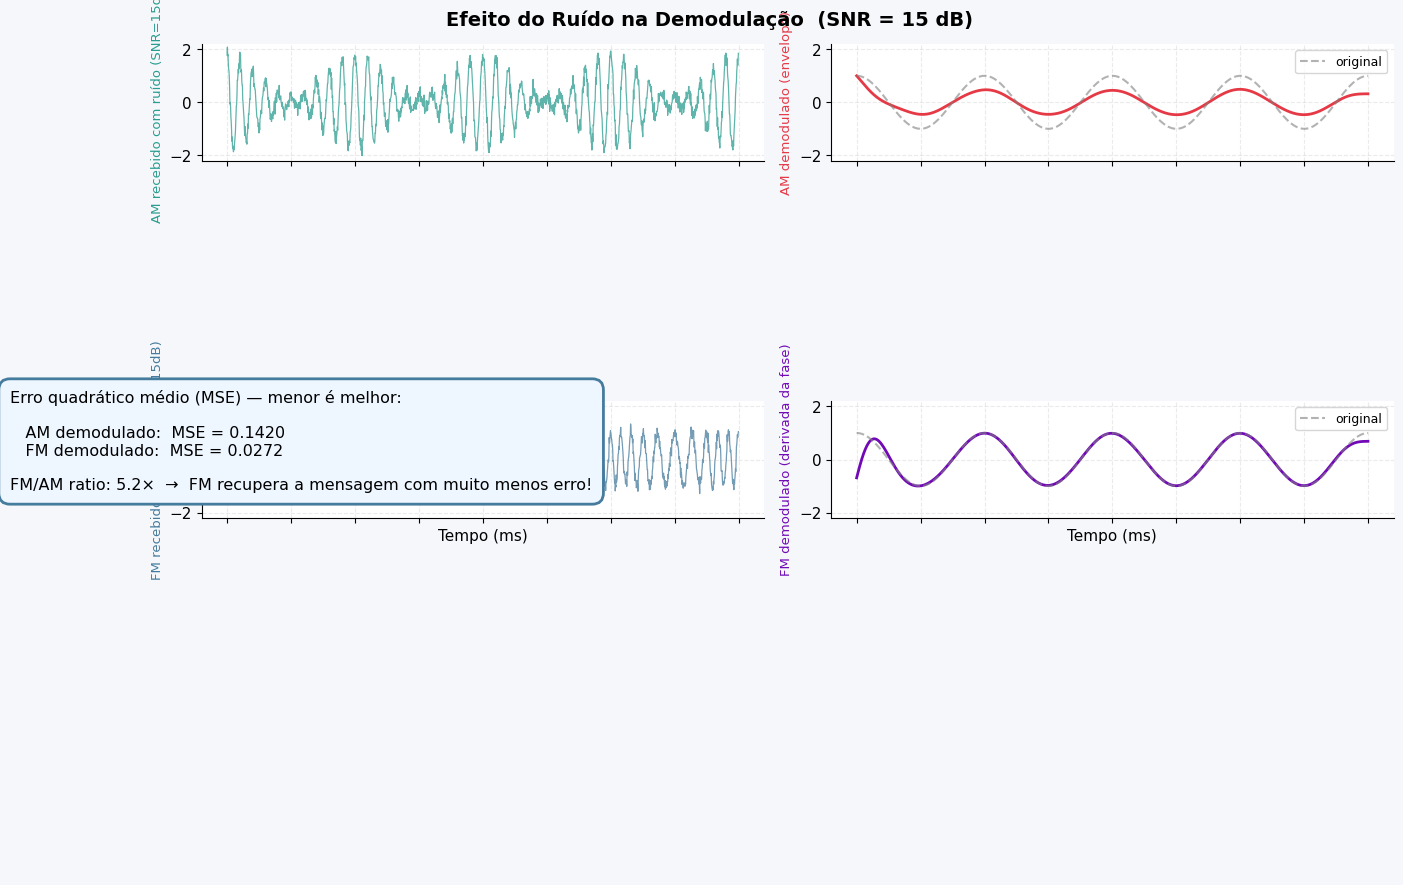

✅ Comparação com ruído gerada!


In [13]:
from scipy.signal import butter, filtfilt

np.random.seed(99)
snr_db    = 15
snr_lin   = 10**(snr_db/10)

def add_noise(sig, snr_lin):
    p   = np.mean(sig**2)
    std = np.sqrt(p / snr_lin)
    return sig + np.random.normal(0, std, len(sig))

am_noisy = add_noise(s_am, snr_lin)
fm_noisy = add_noise(s_fm, snr_lin)

# Demodulação AM: detector de envelope
b_lp, a_lp = butter(4, fm*2.5/(fs/2), btype='low')
am_dem = filtfilt(b_lp, a_lp, np.abs(am_noisy))
am_dem -= np.mean(am_dem)
am_dem /= (np.max(np.abs(am_dem)) + 1e-9)

# Demodulação FM: derivada da fase
analytic_rx = hilbert(fm_noisy)
phase_rx    = np.unwrap(np.angle(analytic_rx))
fm_dem_raw  = np.diff(phase_rx) / (2*np.pi) * fs - fc
fm_dem_raw  = np.append(fm_dem_raw, fm_dem_raw[-1])
fm_dem      = filtfilt(b_lp, a_lp, fm_dem_raw)
fm_dem      /= (np.max(np.abs(fm_dem)) + 1e-9)

fig, axes = plt.subplots(3, 2, figsize=(14, 9), sharex=True)
fig.suptitle(f'Efeito do Ruído na Demodulação  (SNR = {snr_db} dB)',
             fontsize=14, fontweight='bold')

left_col  = [am_noisy,  fm_noisy]
right_col = [am_dem,    fm_dem]
cleft     = ['#2a9d8f', '#457b9d']
cright    = ['#e63946', '#7209b7']
titles_l  = [f'AM recebido com ruído (SNR={snr_db}dB)',
             f'FM recebido com ruído (SNR={snr_db}dB)']
titles_r  = ['AM demodulado (envelope)', 'FM demodulado (derivada da fase)']

for row in range(2):
    axes[row][0].plot(t*1000, left_col[row], color=cleft[row], lw=0.9, alpha=0.75)
    axes[row][0].set_ylabel(titles_l[row], fontsize=9.5, color=cleft[row])

    axes[row][1].plot(t*1000, right_col[row], color=cright[row], lw=2)
    axes[row][1].plot(t*1000, m_t, color='gray', lw=1.5, linestyle='--',
                      alpha=0.6, label='original')
    axes[row][1].set_ylabel(titles_r[row], fontsize=9.5, color=cright[row])
    axes[row][1].legend(fontsize=9)

    for col in range(2):
        axes[row][col].set_ylim(-2.2, 2.2)

# MSE comparison
mse_am = np.mean((am_dem - m_t)**2)
mse_fm = np.mean((fm_dem - m_t)**2)

axes[2][0].axis('off')
axes[2][1].axis('off')

summary_text = (
    f'Erro quadrático médio (MSE) — menor é melhor:\n\n'
    f'   AM demodulado:  MSE = {mse_am:.4f}\n'
    f'   FM demodulado:  MSE = {mse_fm:.4f}\n\n'
    f'FM/AM ratio: {mse_am/mse_fm:.1f}×  →  FM recupera a mensagem com muito menos erro!'
)
axes[2][0].text(0.0, 0.5, summary_text,
                transform=fig.transFigure,
                fontsize=11.5, va='center',
                bbox=dict(boxstyle='round,pad=0.7', facecolor='#eef6ff',
                          edgecolor='#457b9d', lw=2))

for col in range(2):
    axes[1][col].set_xlabel('Tempo (ms)', fontsize=11)

plt.tight_layout()
plt.savefig('11_noise_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparação com ruído gerada!')

---
## 📋 Resumo Final

| | **AM** | **FM** | **PM** |
|-|--------|--------|--------|
| **O que varia** | Amplitude | Frequência | Fase |
| **Amplitude constante?** | ❌ Não | ✅ Sim | ✅ Sim |
| **Equação** | $Ac[1+ka·m]·\cos(2πfct)$ | $Ac·\cos(2πfct+2πkf∫m)$ | $Ac·\cos(2πfct+kp·m)$ |
| **Largura de banda** | $2·fm$ (estreita) | $2(Δf+fm)$ (larga) | similar ao FM |
| **Ruído** | Sensível (afeta amplitude) | Resistente (limita amplitude) | Resistente |
| **Demodulação** | Simples (diodo + RC) | Complexa | Complexa |
| **Aplicação** | Rádio AM, RFID | Rádio FM, TV, Wi-Fi | Satélite, 4G/5G |

---

### Por que o rádio FM soa melhor que o AM?

```
AM: ruído elétrico (raio, motor) → varia a amplitude → o rádio AM ouve o raio!

FM: ruído elétrico varia a amplitude → receptor FM limita a amplitude → ruído descartado!
    só a frequência importa → mensagem limpa
```

> 📌 **PM é a base do digital**: o QAM (visto em outros notebooks) usa modulação de fase e amplitude juntos — é um descendente direto do PM analógico aplicado ao mundo digital.